# 06 — Uncertainty Quantification: lSTM-CNN vs TCN
**Monte Carlo Dropout — both models — PTB-XL ECG Forecasting (4.9s → 4.9s)**


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print("✅ Imports ready")

Device: cpu
✅ Imports ready


In [2]:
# CELL 2 — PATHS & CONFIG
SAVE_DIR  = os.path.join('..', 'data', 'processed')
CKPT_DIR  = os.path.join('..', 'reports', 'checkpoints')
FIG_DIR   = os.path.join('..', 'reports', 'figures', 'uncertainty')
os.makedirs(FIG_DIR, exist_ok=True)

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']
LEAD_NAMES = cfg['lead_names']

print(f"Input   : {INPUT_LEN} samples = {INPUT_LEN/FS:.2f}s")
print(f"Horizon : {HORIZON}  samples = {HORIZON/FS:.2f}s")
print(f"Leads   : {N_LEADS}")
print("✅ Config loaded")

Input   : 490 samples = 4.90s
Horizon : 490  samples = 4.90s
Leads   : 12
✅ Config loaded


In [3]:
# CELL 3 — LOAD TEST DATA
X_test = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

N_UQ   = min(200, len(X_test))
X_uq   = X_test[:N_UQ]
y_uq   = y_test[:N_UQ]

print(f"Using {N_UQ} test samples for UQ")
print(f"X_uq : {X_uq.shape}  y_uq : {y_uq.shape}")
print("✅ Data loaded")

Using 200 test samples for UQ
X_uq : (200, 490, 12)  y_uq : (200, 490, 12)
✅ Data loaded


In [4]:
# CELL 4 — MODEL DEFINITIONS (exact match to training notebooks)

# ── WaveNet (CNN-LSTM notebook model) ─────────────────────────────────
class DilatedBlock(nn.Module):
    def __init__(self, channels, dilation, kernel_size=7, dropout=0.15):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad, bias=False)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad, bias=False)
        self.bn1  = nn.BatchNorm1d(channels)
        self.bn2  = nn.BatchNorm1d(channels)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        res = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = F.gelu(self.bn2(self.conv2(out)))
        out = self.drop(out)
        return out + res

class WaveNetForecaster(nn.Module):
    DILATIONS   = [1, 2, 4, 8, 16, 32, 64]
    CHANNELS    = 64
    KERNEL_SIZE = 7
    def __init__(self, n_leads=12, horizon=490, dropout=0.15):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_leads, self.CHANNELS, kernel_size=1, bias=False),
            nn.BatchNorm1d(self.CHANNELS), nn.GELU())
        self.blocks = nn.ModuleList([
            DilatedBlock(self.CHANNELS, d, self.KERNEL_SIZE, dropout)
            for d in self.DILATIONS])
        self.output_proj = nn.Sequential(
            nn.Conv1d(self.CHANNELS, self.CHANNELS, kernel_size=1, bias=False),
            nn.BatchNorm1d(self.CHANNELS), nn.GELU(),
            nn.Conv1d(self.CHANNELS, n_leads, kernel_size=1))
    def forward(self, x):
        out = self.input_proj(x)
        for block in self.blocks:
            out = block(out)
        return self.output_proj(out).permute(0, 2, 1)
    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

# ── TCN v3 ────────────────────────────────────────────────────────────
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        mid = out_ch // 3
        self.branch3  = nn.Sequential(nn.Conv1d(in_ch, mid, 3,  padding=1,  bias=False), nn.BatchNorm1d(mid), nn.GELU())
        self.branch7  = nn.Sequential(nn.Conv1d(in_ch, mid, 7,  padding=3,  bias=False), nn.BatchNorm1d(mid), nn.GELU())
        self.branch15 = nn.Sequential(nn.Conv1d(in_ch, mid, 15, padding=7,  bias=False), nn.BatchNorm1d(mid), nn.GELU())
        self.project  = nn.Sequential(nn.Conv1d(mid*3, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch), nn.GELU())
        self.residual = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch)) if in_ch != out_ch else nn.Identity()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([self.branch3(x), self.branch7(x), self.branch15(x)], dim=1)
        return F.gelu(self.drop(self.project(out)) + self.residual(x))

class TCNv3Forecaster(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.2):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads
        self.enc1 = nn.Sequential(MultiScaleBlock(n_leads, 64,  dropout), nn.MaxPool1d(2))
        self.enc2 = nn.Sequential(MultiScaleBlock(64,      128, dropout), nn.MaxPool1d(2))
        self.enc3 = MultiScaleBlock(128, 128, dropout)
        self.attn = nn.Sequential(nn.Linear(128, 64), nn.Tanh(), nn.Linear(64, 1))
        self.decoder = nn.Sequential(
            nn.LayerNorm(128), nn.Dropout(dropout),
            nn.Linear(128, 256), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(256, horizon * n_leads))
    def forward(self, x):
        x = self.enc3(self.enc2(self.enc1(x))).permute(0, 2, 1)
        ctx = (torch.softmax(self.attn(x), dim=1) * x).sum(dim=1)
        return self.decoder(ctx).view(-1, self.horizon, self.n_leads)
    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

print("✅ Both model classes defined")

✅ Both model classes defined


In [5]:
# CELL 5 — LOAD WEIGHTS
def load_ckpt(model, path, name):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        sd   = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
        model.load_state_dict(sd)
        n = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"✅ {name} loaded  ({n:,} params)")
    else:
        print(f"⚠  {name} checkpoint not found — using random weights")
    model.eval()

wave_model = WaveNetForecaster(n_leads=N_LEADS, horizon=HORIZON, dropout=0.15).to(DEVICE)
tcn_model  = TCNv3Forecaster(n_leads=N_LEADS,  horizon=HORIZON, dropout=0.2).to(DEVICE)

load_ckpt(wave_model, os.path.join(CKPT_DIR, 'CNN-LSTM_final.pt'), 'LSTM-CNN')
load_ckpt(tcn_model,  os.path.join(CKPT_DIR, 'TCN_final.pt'),      'TCN')

✅ LSTM-CNN loaded  (409,100 params)
✅ TCN loaded  (1,807,563 params)


In [6]:
# CELL 6 — MC DROPOUT ENGINE
def mc_predict(model, X_np, n_iter=50, batch=64, channel_first=True):
    """Returns (n_iter, N, HORIZON, n_leads)"""
    model.enable_mc_dropout()
    Xt = torch.tensor(X_np, dtype=torch.float32)
    all_preds = []
    with torch.no_grad():
        for _ in tqdm(range(n_iter), desc='MC passes', leave=False):
            preds = []
            for i in range(0, len(Xt), batch):
                xb = Xt[i:i+batch].to(DEVICE)
                if channel_first: xb = xb.permute(0, 2, 1)
                preds.append(model(xb).cpu().numpy())
            all_preds.append(np.concatenate(preds))
    return np.array(all_preds)

N_ITER = 50
print(f"Running {N_ITER} MC iterations per model …")
wave_mc = mc_predict(wave_model, X_uq, N_ITER, channel_first=True)
print(f"LSTM-CNN MC: {wave_mc.shape}")
tcn_mc  = mc_predict(tcn_model,  X_uq, N_ITER, channel_first=True)
print(f"TCN  MC: {tcn_mc.shape}")

wave_mean = wave_mc.mean(0); wave_std = wave_mc.std(0)
tcn_mean  = tcn_mc.mean(0);  tcn_std  = tcn_mc.std(0)
print("✅ MC predictions ready")

Running 50 MC iterations per model …


MC passes:   0%|          | 0/50 [00:00<?, ?it/s]

LSTM-CNN MC: (50, 200, 490, 12)


MC passes:   0%|          | 0/50 [00:00<?, ?it/s]

TCN  MC: (50, 200, 490, 12)
✅ MC predictions ready


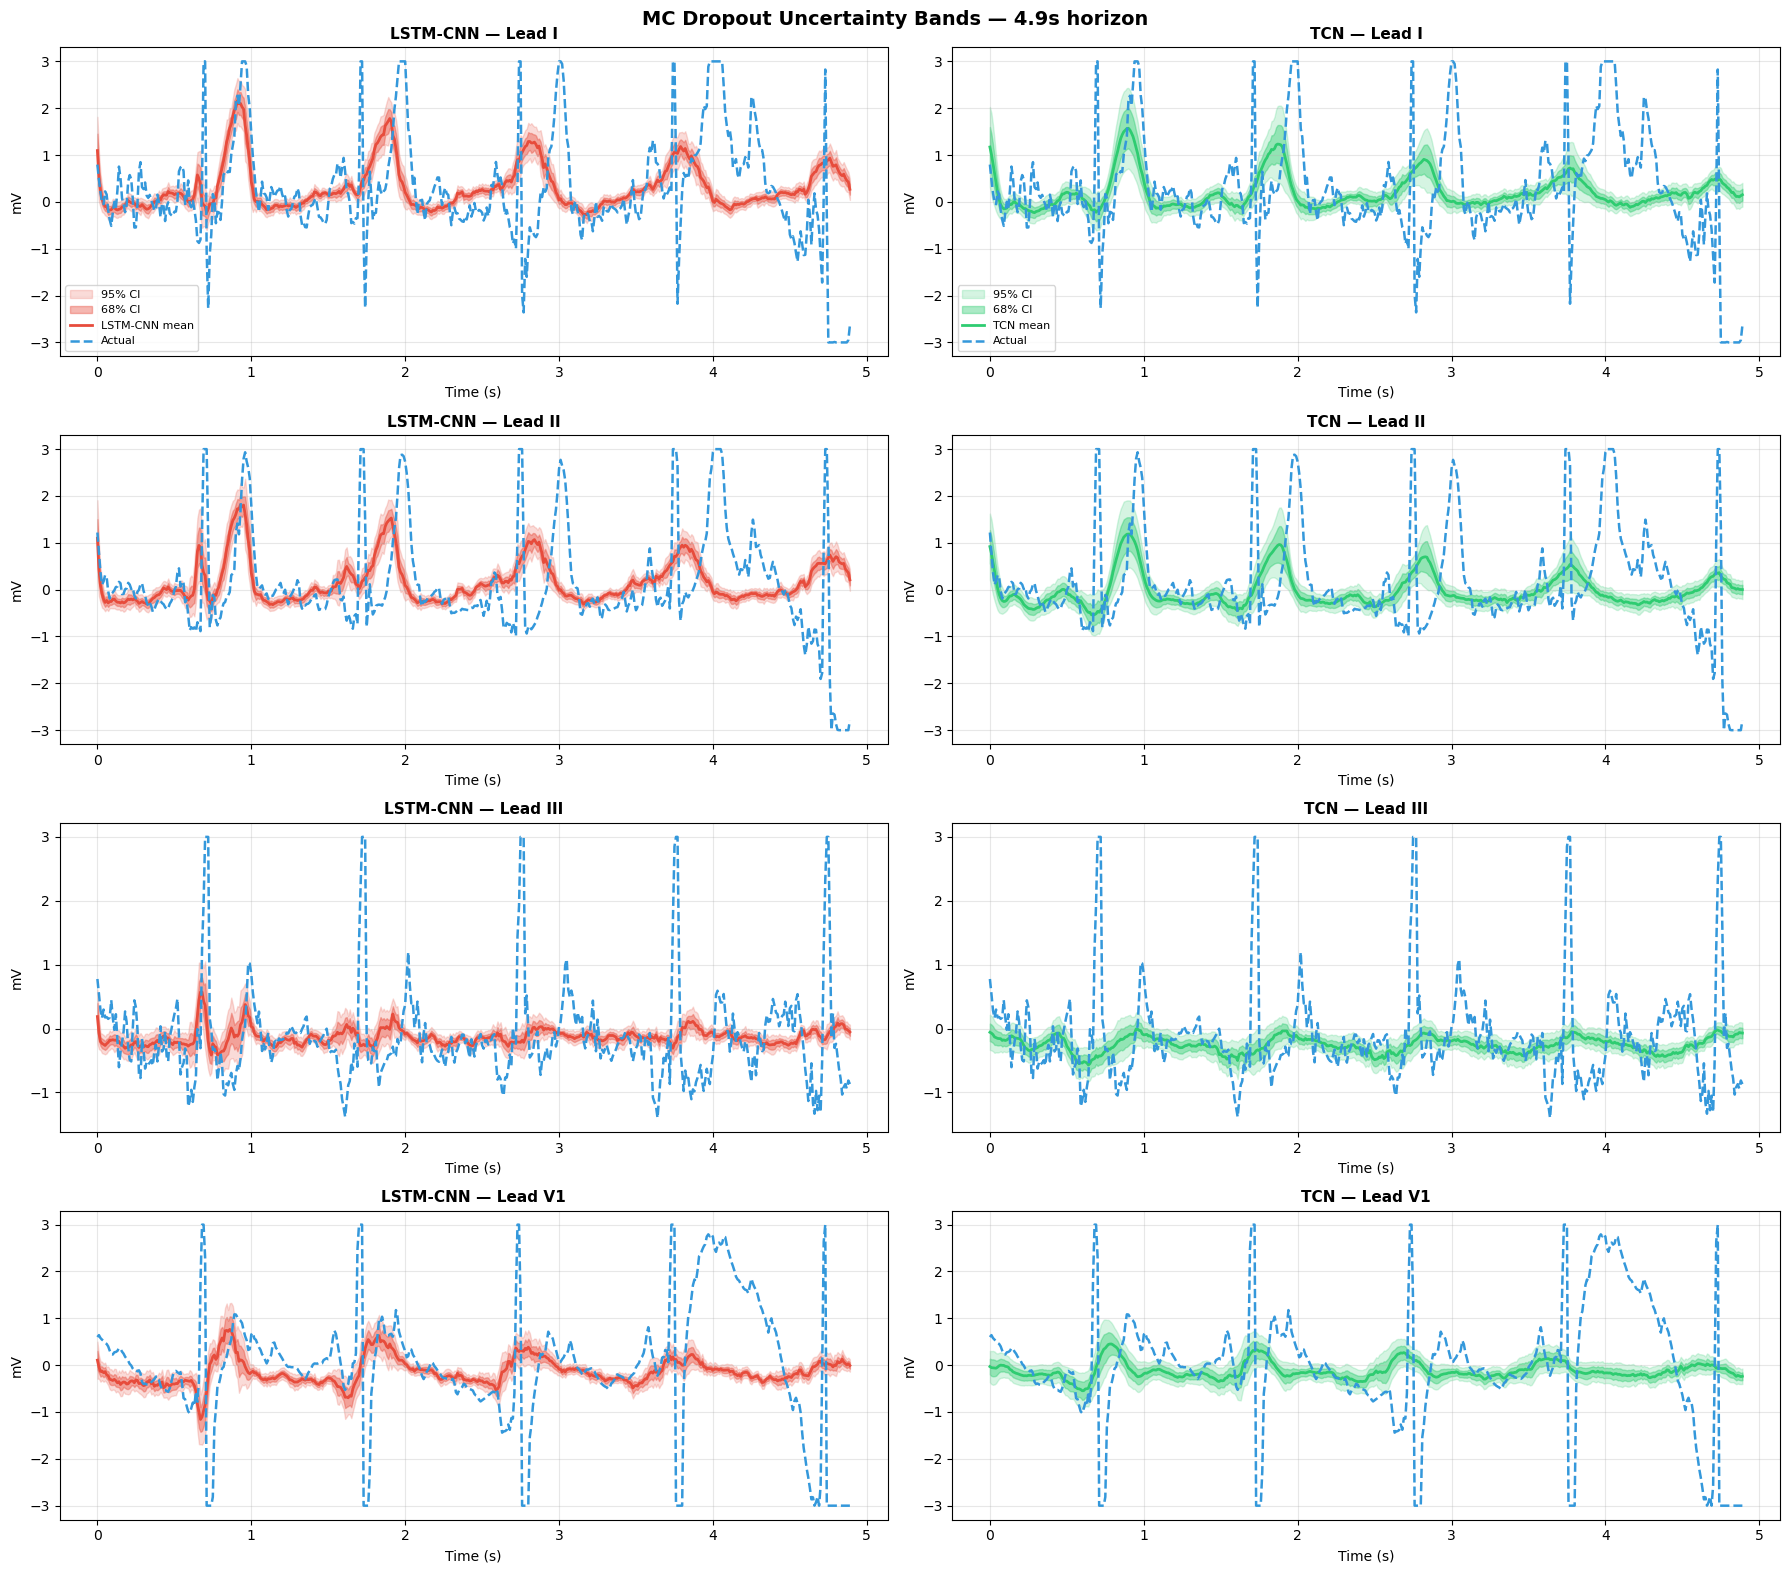

✅ Saved 01_uncertainty_bands.png


In [7]:
# CELL 7 — UNCERTAINTY BANDS (sample overlay)
SAMPLE = 0
LEADS  = [0, 1, 2, 6]
t = np.arange(HORIZON) / FS

fig, axes = plt.subplots(len(LEADS), 2, figsize=(18, 4*len(LEADS)))
for row, li in enumerate(LEADS):
    for col, (name, mean, std, color) in enumerate([
        ('LSTM-CNN', wave_mean, wave_std, '#e74c3c'),
        ('TCN',  tcn_mean,  tcn_std,  '#2ecc71'),
    ]):
        ax = axes[row, col]
        ym = mean[SAMPLE, :, li]; ys = std[SAMPLE, :, li]
        yt = y_uq[SAMPLE, :, li]
        ax.fill_between(t, ym-2*ys, ym+2*ys, alpha=0.2, color=color, label='95% CI')
        ax.fill_between(t, ym-ys,   ym+ys,   alpha=0.4, color=color, label='68% CI')
        ax.plot(t, ym, color=color,     lw=2,   label=f'{name} mean')
        ax.plot(t, yt, color='#3498db', lw=1.8, label='Actual', ls='--')
        ax.set_title(f'{name} — Lead {LEAD_NAMES[li]}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.grid(alpha=0.3)
        if row == 0: ax.legend(fontsize=8)

fig.suptitle(f'MC Dropout Uncertainty Bands — {HORIZON/FS:.1f}s horizon',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_uncertainty_bands.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 01_uncertainty_bands.png")

                 Epistemic     Aleatoric
LSTM-CNN            0.1594        0.7099
TCN                 0.1688        0.7271


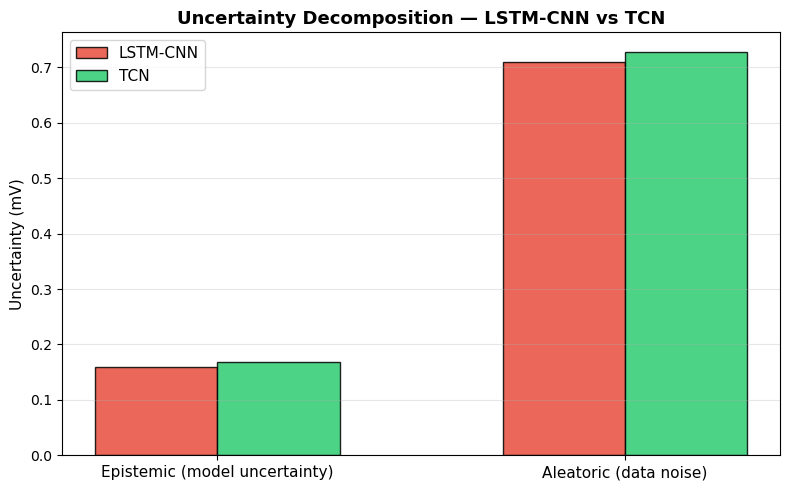

✅ Saved 02_uncertainty_decomposition.png


In [8]:
# CELL 8 — EPISTEMIC vs ALEATORIC DECOMPOSITION
wave_ep = float(wave_std.mean())
wave_al = float(np.abs(wave_mean - y_uq).mean())
tcn_ep  = float(tcn_std.mean())
tcn_al  = float(np.abs(tcn_mean  - y_uq).mean())

print(f"{'':12s}  {'Epistemic':>12s}  {'Aleatoric':>12s}")
print(f"{'LSTM-CNN':12s}  {wave_ep:>12.4f}  {wave_al:>12.4f}")
print(f"{'TCN':12s}  {tcn_ep:>12.4f}  {tcn_al:>12.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.3
ax.bar(x-w/2, [wave_ep, wave_al], w, label='LSTM-CNN', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.bar(x+w/2, [tcn_ep,  tcn_al],  w, label='TCN',  color='#2ecc71', alpha=0.85, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Epistemic (model uncertainty)', 'Aleatoric (data noise)'], fontsize=11)
ax.set_ylabel('Uncertainty (mV)', fontsize=11)
ax.set_title('Uncertainty Decomposition — LSTM-CNN vs TCN', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_uncertainty_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 02_uncertainty_decomposition.png")

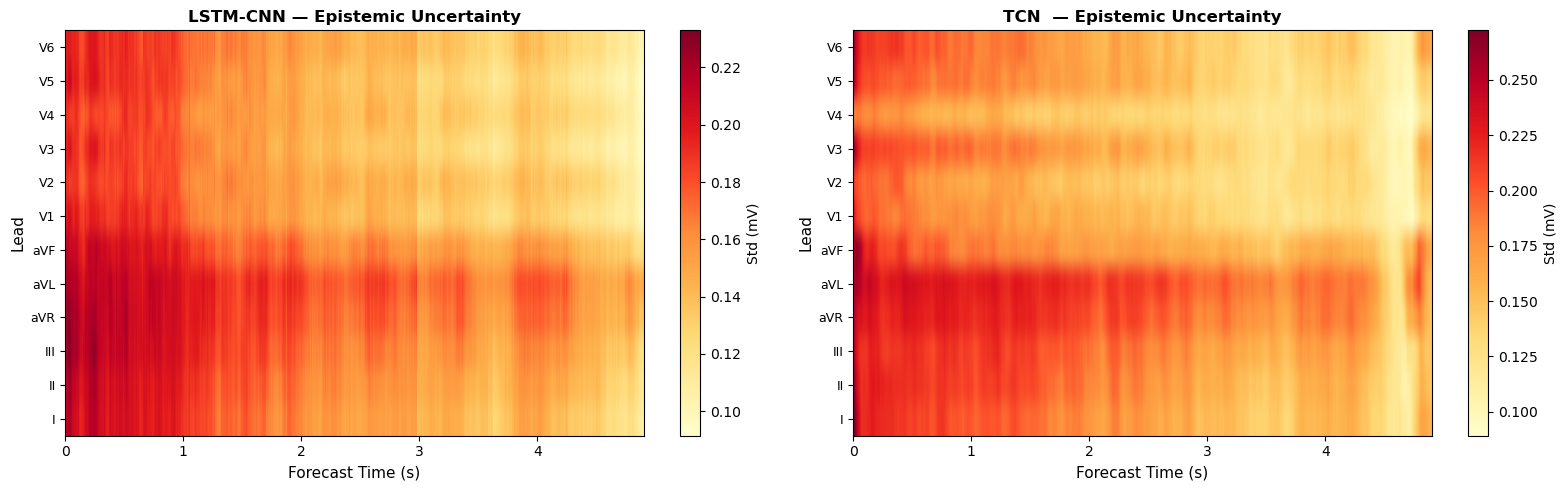

✅ Saved 03_uncertainty_heatmap.png


In [9]:
# CELL 9 — UNCERTAINTY HEATMAP (Lead × Time)
wave_std_mean = wave_std.mean(axis=0)   # (HORIZON, 12)
tcn_std_mean  = tcn_std.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, data, title in [
    (axes[0], wave_std_mean, 'LSTM-CNN — Epistemic Uncertainty'),
    (axes[1], tcn_std_mean,  'TCN  — Epistemic Uncertainty'),
]:
    im = ax.imshow(data.T, aspect='auto', cmap='YlOrRd',
                   extent=[0, HORIZON/FS, -0.5, N_LEADS-0.5])
    ax.set_xlabel('Forecast Time (s)', fontsize=11)
    ax.set_ylabel('Lead', fontsize=11)
    ax.set_yticks(range(N_LEADS))
    ax.set_yticklabels(LEAD_NAMES, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    plt.colorbar(im, ax=ax, label='Std (mV)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_uncertainty_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 03_uncertainty_heatmap.png")

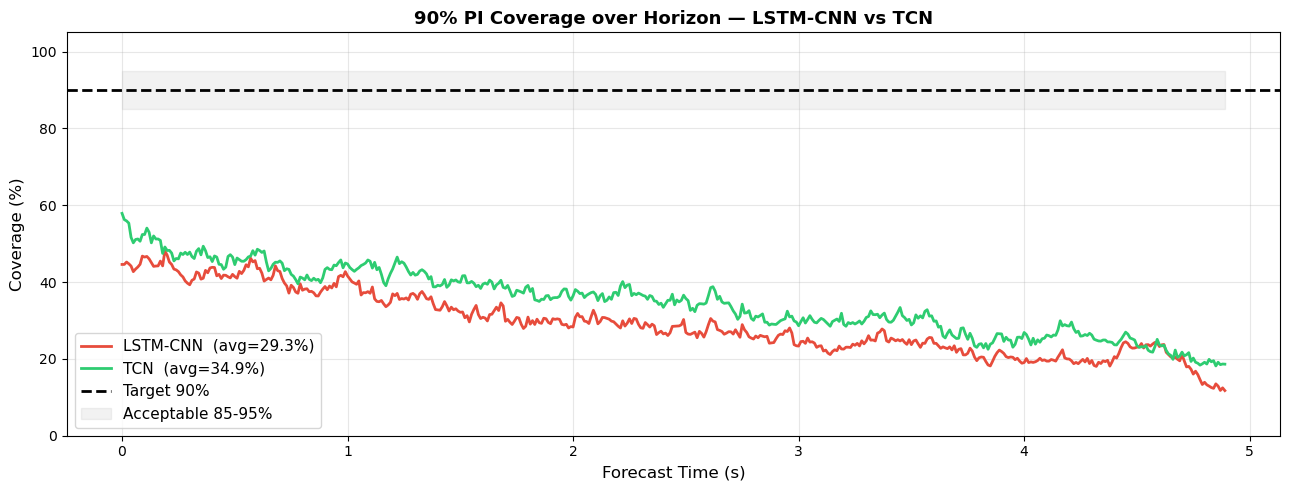

✅ Saved 04_coverage_analysis.png


In [10]:
# CELL 10 — 90% PREDICTION INTERVAL COVERAGE
t_steps = np.arange(HORIZON) / FS
fig, ax = plt.subplots(figsize=(13, 5))

for name, mean, std, color in [
    ('LSTM-CNN', wave_mean, wave_std, '#e74c3c'),
    ('TCN',  tcn_mean,  tcn_std,  '#2ecc71'),
]:
    lower = mean - 1.645 * std
    upper = mean + 1.645 * std
    cov   = ((y_uq >= lower) & (y_uq <= upper)).mean(axis=(0, 2)) * 100
    ax.plot(t_steps, cov, lw=2, color=color,
            label=f'{name}  (avg={cov.mean():.1f}%)')

ax.axhline(90, color='black', ls='--', lw=2, label='Target 90%')
ax.fill_between(t_steps, 85, 95, alpha=0.1, color='grey', label='Acceptable 85-95%')
ax.set_xlabel('Forecast Time (s)', fontsize=12)
ax.set_ylabel('Coverage (%)', fontsize=12)
ax.set_title('90% PI Coverage over Horizon — LSTM-CNN vs TCN',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 105]); ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_coverage_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 04_coverage_analysis.png")

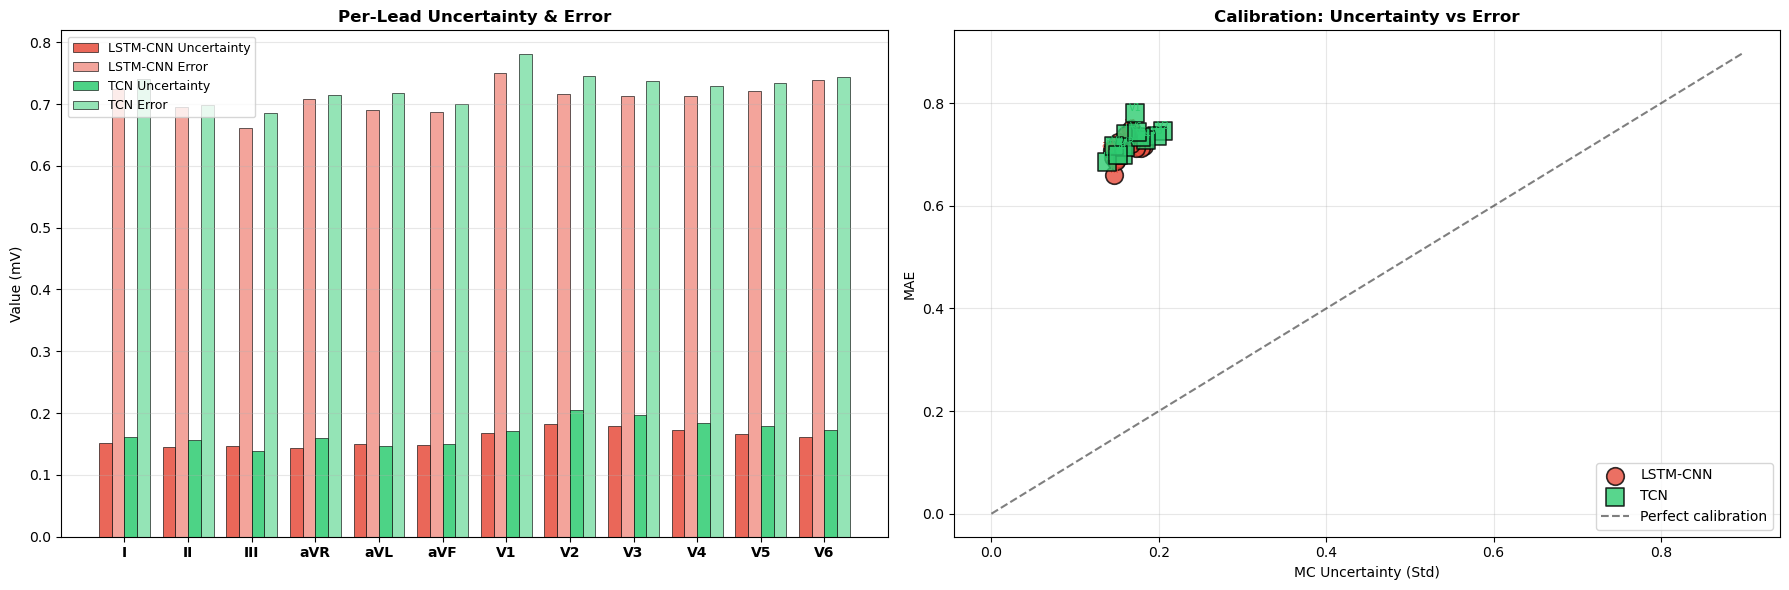

✅ Saved 05_per_lead_calibration.png


In [11]:
# CELL 11 — PER-LEAD CALIBRATION
wave_std_lead = wave_std.mean(axis=(0,1))              # (12,)
wave_err_lead = np.abs(wave_mean - y_uq).mean(axis=(0,1))
tcn_std_lead  = tcn_std.mean(axis=(0,1))
tcn_err_lead  = np.abs(tcn_mean  - y_uq).mean(axis=(0,1))

x = np.arange(N_LEADS); w = 0.2
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for off, vals, lbl, color in [
    (-1.5*w, wave_std_lead, 'LSTM-CNN Uncertainty', '#e74c3c'),
    (-0.5*w, wave_err_lead, 'LSTM-CNN Error',       '#f1948a'),
    ( 0.5*w, tcn_std_lead,  'TCN Uncertainty',  '#2ecc71'),
    ( 1.5*w, tcn_err_lead,  'TCN Error',        '#82e0aa'),
]:
    axes[0].bar(x+off, vals, w, label=lbl, color=color, alpha=0.85, edgecolor='black', lw=0.5)

axes[0].set_xticks(x); axes[0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0].set_ylabel('Value (mV)'); axes[0].legend(fontsize=9)
axes[0].set_title('Per-Lead Uncertainty & Error', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

for std_l, err_l, name, color, marker in [
    (wave_std_lead, wave_err_lead, 'LSTM-CNN', '#e74c3c', 'o'),
    (tcn_std_lead,  tcn_err_lead,  'TCN',  '#2ecc71', 's'),
]:
    axes[1].scatter(std_l, err_l, s=160, alpha=0.8, color=color,
                    edgecolor='black', lw=1.2, marker=marker, label=name, zorder=3)
    for i, lead in enumerate(LEAD_NAMES):
        axes[1].annotate(lead, (std_l[i], err_l[i]),
                         fontsize=7, ha='center', va='bottom', color=color)

mx = max(wave_std_lead.max(), wave_err_lead.max(),
         tcn_std_lead.max(),  tcn_err_lead.max()) * 1.15
axes[1].plot([0,mx],[0,mx],'k--',lw=1.5,alpha=0.5,label='Perfect calibration')
axes[1].set_xlabel('MC Uncertainty (Std)'); axes[1].set_ylabel('MAE')
axes[1].set_title('Calibration: Uncertainty vs Error', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_per_lead_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 05_per_lead_calibration.png")

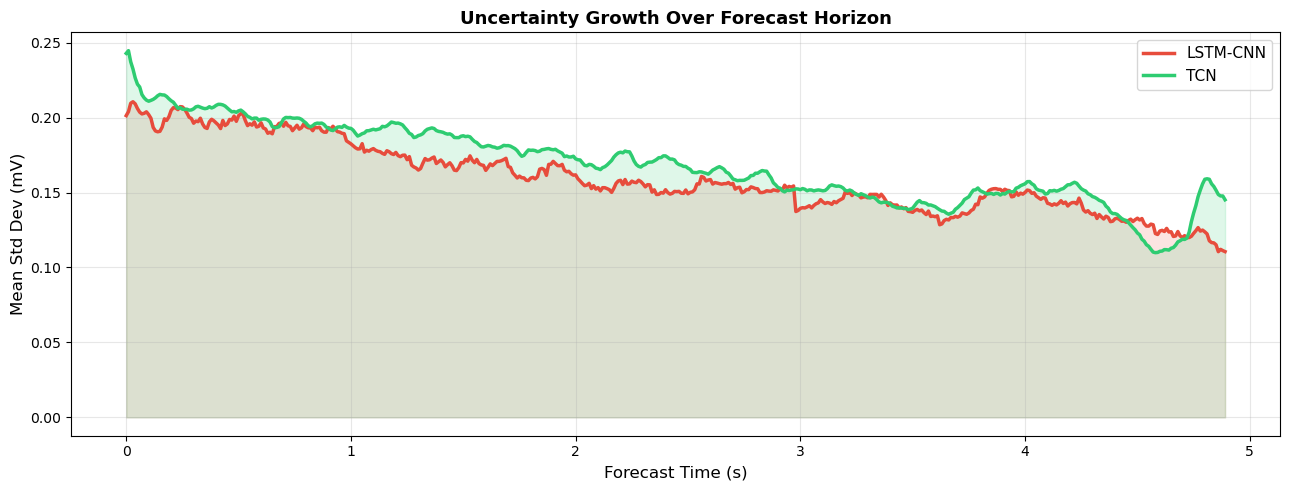

✅ Saved 06_uncertainty_growth.png


In [12]:
# CELL 12 — UNCERTAINTY GROWTH OVER HORIZON
wave_std_t = wave_std.mean(axis=(0,2))   # (HORIZON,)
tcn_std_t  = tcn_std.mean(axis=(0,2))
t = np.arange(HORIZON) / FS

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t, wave_std_t, color='#e74c3c', lw=2.5, label='LSTM-CNN')
ax.plot(t, tcn_std_t,  color='#2ecc71', lw=2.5, label='TCN')
ax.fill_between(t, wave_std_t, alpha=0.15, color='#e74c3c')
ax.fill_between(t, tcn_std_t,  alpha=0.15, color='#2ecc71')
ax.set_xlabel('Forecast Time (s)', fontsize=12)
ax.set_ylabel('Mean Std Dev (mV)', fontsize=12)
ax.set_title('Uncertainty Growth Over Forecast Horizon',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_uncertainty_growth.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved 06_uncertainty_growth.png")

In [13]:
# CELL 13 — SUMMARY TABLE
wave_cov = ((y_uq >= wave_mean-1.645*wave_std) & (y_uq <= wave_mean+1.645*wave_std)).mean()*100
tcn_cov  = ((y_uq >= tcn_mean -1.645*tcn_std)  & (y_uq <= tcn_mean +1.645*tcn_std)).mean()*100

print("\n" + "="*65)
print("  UNCERTAINTY QUANTIFICATION SUMMARY")
print("="*65)
print(f"  Config  : {INPUT_LEN/FS:.1f}s input → {HORIZON/FS:.1f}s horizon | {N_ITER} MC iters | {N_UQ} samples")
print()
print(f"  {'Metric':32s}  {'LSTM-CNN':>10s}  {'TCN':>10s}")
print(f"  {'-'*55}")
print(f"  {'Mean uncertainty (mV)':32s}  {wave_std.mean():>10.4f}  {tcn_std.mean():>10.4f}")
print(f"  {'Aleatoric / mean error (mV)':32s}  {wave_al:>10.4f}  {tcn_al:>10.4f}")
print(f"  {'Epistemic uncertainty':32s}  {wave_ep:>10.4f}  {tcn_ep:>10.4f}")
print(f"  {'90% CI coverage (%)':32s}  {wave_cov:>10.1f}  {tcn_cov:>10.1f}")
print(f"  {'Highest-uncertainty lead':32s}  {LEAD_NAMES[np.argmax(wave_std_lead)]:>10s}  {LEAD_NAMES[np.argmax(tcn_std_lead)]:>10s}")
print(f"  {'Most-predictable lead':32s}  {LEAD_NAMES[np.argmin(wave_err_lead)]:>10s}  {LEAD_NAMES[np.argmin(tcn_err_lead)]:>10s}")
print()
print("  Figures:")
for i, n in enumerate(['01_uncertainty_bands','02_uncertainty_decomposition',
                        '03_uncertainty_heatmap','04_coverage_analysis',
                        '05_per_lead_calibration','06_uncertainty_growth'], 1):
    print(f"    {i}. {n}.png")
print("\n✅ UQ Complete")


  UNCERTAINTY QUANTIFICATION SUMMARY
  Config  : 4.9s input → 4.9s horizon | 50 MC iters | 200 samples

  Metric                              LSTM-CNN         TCN
  -------------------------------------------------------
  Mean uncertainty (mV)                 0.1594      0.1688
  Aleatoric / mean error (mV)           0.7099      0.7271
  Epistemic uncertainty                 0.1594      0.1688
  90% CI coverage (%)                     29.3        34.9
  Highest-uncertainty lead                  V2          V2
  Most-predictable lead                    III         III

  Figures:
    1. 01_uncertainty_bands.png
    2. 02_uncertainty_decomposition.png
    3. 03_uncertainty_heatmap.png
    4. 04_coverage_analysis.png
    5. 05_per_lead_calibration.png
    6. 06_uncertainty_growth.png

✅ UQ Complete


In [14]:
# CELL 14 — SAVE RESULTS
results = {
    'lstm_cnn_mc_mean': wave_mean, 'lstm_cnn_mc_std': wave_std,
    'tcn_mc_mean':  tcn_mean,  'tcn_mc_std':  tcn_std,
    'lstm_cnn_epistemic': wave_ep, 'lstm_cnn_aleatoric': wave_al,
    'tcn_epistemic':  tcn_ep,  'tcn_aleatoric':  tcn_al,
    'lstm_cnn_cov_90': float(wave_cov), 'tcn_cov_90': float(tcn_cov),
    'lstm_cnn_std_lead': wave_std_lead.tolist(),
    'tcn_std_lead':  tcn_std_lead.tolist(),
    'lstm_cnn_err_lead': wave_err_lead.tolist(),
    'tcn_err_lead':  tcn_err_lead.tolist(),
    'lead_names': LEAD_NAMES, 'horizon_s': HORIZON/FS,
    'input_s': INPUT_LEN/FS, 'n_iter': N_ITER, 'n_samples': N_UQ,
}
path = os.path.join(FIG_DIR, 'uncertainty_results.pkl')
with open(path, 'wb') as f: pickle.dump(results, f)
print(f"✅ Results saved → {path}")

✅ Results saved → ../reports/figures/uncertainty/uncertainty_results.pkl
